In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import ast

PATH_DATA = "../Dataset/Data/Processed/data.csv"
PATH_ACTIONS = "../Dataset/Data/tmp/actions_filtered.csv"

PATH_TEST = "test_out.csv"
TEST_CLIP = "1/11_Left.mp4"
PATH_CLIPS = "../Dataset/Videos/Clips/"

In [ ]:
df_data = pd.read_csv(PATH_DATA)
unique_labels = sorted(df_data["action"].unique())

labels = pd.DataFrame(unique_labels, columns=["action"])
labels["id"] = labels["action"].map(dict)

labels.rename(columns={"action": "label"}, inplace=True)
labels.to_csv("label_map.csv", index=False)

print(labels)

In [10]:
df_actions = pd.read_csv(PATH_ACTIONS)
true_actions = df_actions[df_actions["file"] == TEST_CLIP]

print(true_actions)

            file fencer  action_id                 action  start_frame  \
2  1/11_Left.mp4   LEFT          2           ATTACK_LUNGE           60   
3  1/11_Left.mp4  RIGHT          3  DEFENSE_DISTANCE_PULL           22   
4  1/11_Left.mp4  RIGHT          4         ATTACK_COUNTER           56   

   end_frame  
2         65  
3         40  
4         61  


In [ ]:
df_test = pd.read_csv(PATH_TEST)

merged = df_test.merge(
    true_actions[["fencer", "action", "start_frame", "end_frame"]],
    on="fencer",
    how="left"
)

valid = merged[
    (merged["frame"] >= merged["start_frame"]) &
    (merged["frame"] <= merged["end_frame"])
]

df_filtered = (
    valid[["fencer", "frame", "action", "pred_label", "confidence", "box","keypoints"]]
    .drop_duplicates()
    .sort_values(["fencer", "frame"])
    .reset_index(drop=True)
)

df_filtered["box"] = df_filtered["box"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

df_filtered["keypoints"] = df_filtered["keypoints"].apply(
    lambda x: [tuple(p) for p in ast.literal_eval(x)] if isinstance(x, str) else x
)

print(df_filtered)

   fencer  frame                 action             pred_label  confidence  \
0    LEFT     60           ATTACK_LUNGE         ATTACK_COUNTER    0.848136   
1    LEFT     61           ATTACK_LUNGE         ATTACK_COUNTER    0.859552   
2    LEFT     62           ATTACK_LUNGE         ATTACK_COUNTER    0.815628   
3    LEFT     63           ATTACK_LUNGE         ATTACK_COUNTER    0.828059   
4    LEFT     64           ATTACK_LUNGE           ATTACK_LUNGE    0.823081   
5    LEFT     65           ATTACK_LUNGE           ATTACK_LUNGE    0.829528   
6   RIGHT     22  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER    0.865147   
7   RIGHT     23  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER    0.813983   
8   RIGHT     24  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER    0.851604   
9   RIGHT     25  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER    0.895800   
10  RIGHT     26  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER    0.851080   
11  RIGHT     27  DEFENSE_DISTANCE_PULL         ATTACK_COUNTER  

In [37]:
EDGES = [
    (0, 1), (1, 3),
    (3, 5), (1, 2),
    (0, 2), (2, 4),
    (4, 6),
    (5, 7), (7, 9),     # left arm
    (6, 8), (8, 10),    # right arm
    (5, 6),             # shoulders
    (11, 12),           # hips
    (5, 11), (6, 12),   # torso
    (11, 13), (13, 15), # left leg
    (12, 14), (14, 16)  # right leg
]

def plot_skeleton(frame, keypoints, color=(0,1,0), alpha=0.8):
    for (i,j) in EDGES:
        if i >= len(keypoints) or j >= len(keypoints):
            continue
        x1, y1 = keypoints[i]
        x2, y2 = keypoints[j]
        plt.plot([x1, x2], [y1, y2], color=color, alpha=alpha, linewidth=2)
    keypoints = np.array(keypoints)
    plt.scatter(keypoints[:,0], keypoints[:,1], color=color, s=20)

def draw_random_frame(df):
    # Pick a random row from the dataframe
    row = df.sample(1).iloc[0]
    video_path = PATH_CLIPS + TEST_CLIP
    frame_idx = row["frame"]
    keypoints = row["keypoints"]
    box = row["box"]
    confidence = row["confidence"]

    # Open video
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {frame_idx}")
        return

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,6))
    plt.imshow(frame_rgb)
    plt.axis("off")

    # Draw bounding box
    if box and not isinstance(box, float):
        x1, y1, x2, y2 = box
        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=2))

    # Draw skeleton
    if keypoints and not (isinstance(keypoints, float) and np.isnan(keypoints)):
        plot_skeleton(frame_rgb, keypoints, color=(0,1,0))

    plt.title(f"Frame {frame_idx}, Fencer: {row['fencer']}, Action: {row['action']}, Prediction: {row['pred_label']}, Confidence: {confidence:.2f}")
    plt.show()

    cap.release()

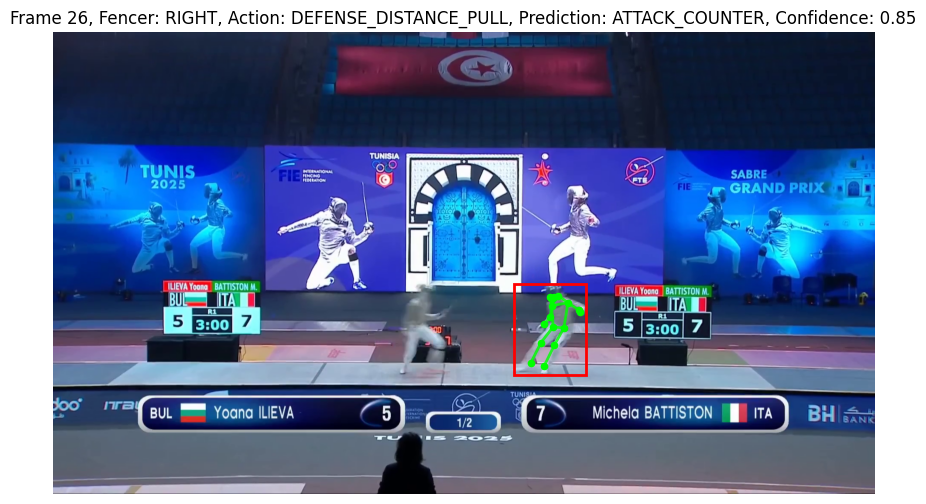

In [56]:
draw_random_frame(df_filtered)